In [18]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [3]:
# Path to audio files
data_path = r"../data"
genres = os.listdir(data_path)

# Labels mapping
genre_mapping = {genre: idx for idx, genre in enumerate(genres)}

# Data storage
features = []
labels = []

In [11]:
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=None, duration=30)
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=128)
        # Ensure consistent shape by padding/truncating
        if mfccs.shape[1] < 128:
            padded_mfccs = np.pad(mfccs, ((0, 0), (0, 128 - mfccs.shape[1])), mode='constant')
        else:
            padded_mfccs = mfccs[:, :128]
        mfccs_scaled = np.mean(padded_mfccs.T, axis=0)
        return mfccs_scaled
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return 


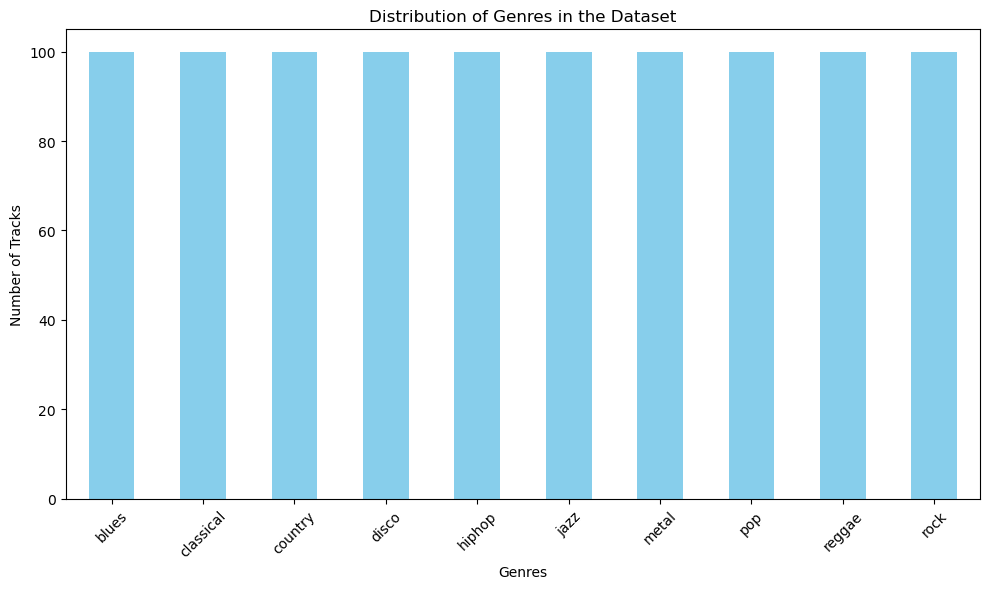

In [5]:
# Create a DataFrame for visualization
df = pd.DataFrame({'Genre': [genres[label] for label in labels]})
df['Count'] = 1

# Plot the distribution of genres
plt.figure(figsize=(10, 6))
df.groupby('Genre')['Count'].count().plot(kind='bar', color='skyblue')
plt.title("Distribution of Genres in the Dataset")
plt.xlabel("Genres")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

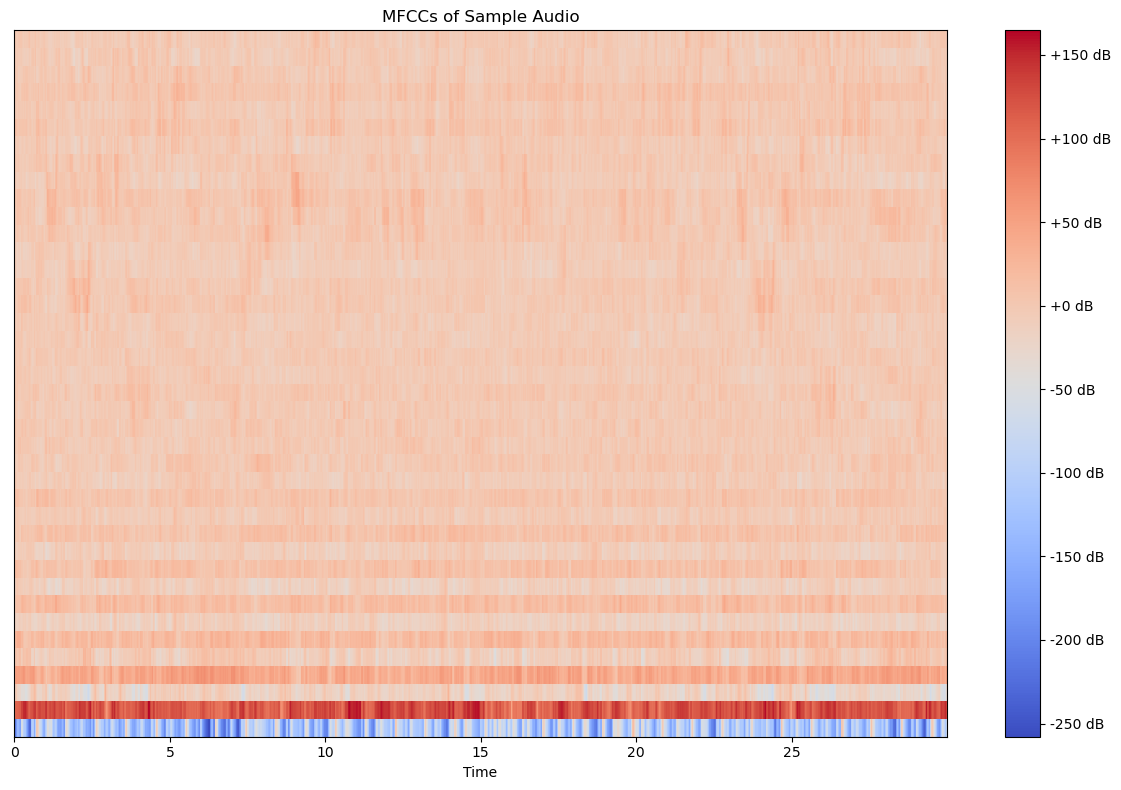

In [6]:
# Visualize MFCCs for a sample audio file
sample_audio_path = os.path.join(data_path, genres[0], os.listdir(os.path.join(data_path, genres[0]))[0])
audio, sr = librosa.load(sample_audio_path, duration=30)
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

plt.figure(figsize=(12, 8))
librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap='coolwarm')
plt.colorbar(format='%+2.0f dB')
plt.title("MFCCs of Sample Audio")
plt.tight_layout()
plt.show()

In [12]:
valid_features = [f for f in features if f is not None]
valid_labels = [labels[i] for i, f in enumerate(features) if f is not None]

X = np.array(valid_features)
y = np.array(valid_labels)


In [13]:
# Function to extract features
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=None, duration=30)
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=128)
        # Ensure consistent shape
        if mfccs.shape[1] < 128:
            padded_mfccs = np.pad(mfccs, ((0, 0), (0, 128 - mfccs.shape[1])), mode='constant')
        else:
            padded_mfccs = mfccs[:, :128]
        mfccs_scaled = np.mean(padded_mfccs.T, axis=0)
        return mfccs_scaled
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Filter out invalid entries
valid_features = [f for f in features if f is not None]
valid_labels = [labels[i] for i, f in enumerate(features) if f is not None]

# Convert to NumPy arrays
X = np.array(valid_features)
y = np.array(valid_labels)

# One-hot encoding of labels
y_one_hot = to_categorical(y, num_classes=len(genres))

# Train-Test-Validation split
X_train, X_temp, y_train, y_temp = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Shapes: X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")


Shapes: X_train: (799, 128), X_val: (100, 128), X_test: (100, 128)


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on the test set
model = tf.keras.models.load_model('audio_cnn_model.h5')
y_pred = model.h5.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genres)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'audio_cnn_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)